In [87]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import math

In [140]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda:None # By default doesn't anything
        self._prev = set(_children) #_children is an internal argument used to build a computataional graph
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})" # To Print nicely
    
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other) # If other is not a Value instance, convert it to a Value instance
        out = Value(self.data + other.data, (self, other), '+') # overrides python's default + operator for Value class case
        
        def _backward():
            self.grad += 1.0 * out.grad # Accumulate gradients (If not, it will overwrite the gradient Bug case a + a gradient will be 1.0 instead od 2.0))
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __radd__(self, other):
        return self + other  # This allows for scalar addition from the left (e.g., 2 + Value)
    
    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1) * out.grad)

        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other  # This allows for scalar multiplication from the left (e.g., 2 * Value)

    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other ** -1  # Division is multiplication by the reciprocal
    
    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): #self - other
        return self + (-other)
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.grad * out.data
        out._backward = _backward

        return out
    
    def backward(self):
        # Topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [39]:
from graphviz import Digraph
import graphviz

def trace(root):
    nodes = set()
    edges = set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = graphviz.Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            op_uid = uid + n._op
            dot.node(op_uid, n._op)
            dot.edge(op_uid, uid)
        for child in n._prev:
            dot.edge(str(id(child)), uid + n._op)
    return dot

In [ ]:
# Nudge Values a little bit in the direction of the gradient

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f
# This showed a change in the value of L, i.e. l increased positively with positive increase of gradient
print(L.data) 



-5.900192000000001


In [46]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L2 = L.data

    print((L2-L1)/h)

lol()

6.000000000021544


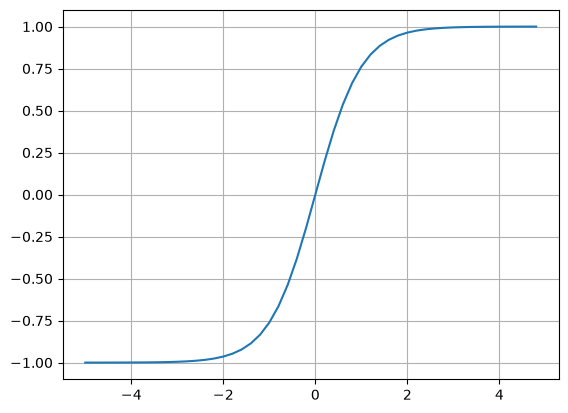

In [4]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1w1+x2w2+b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

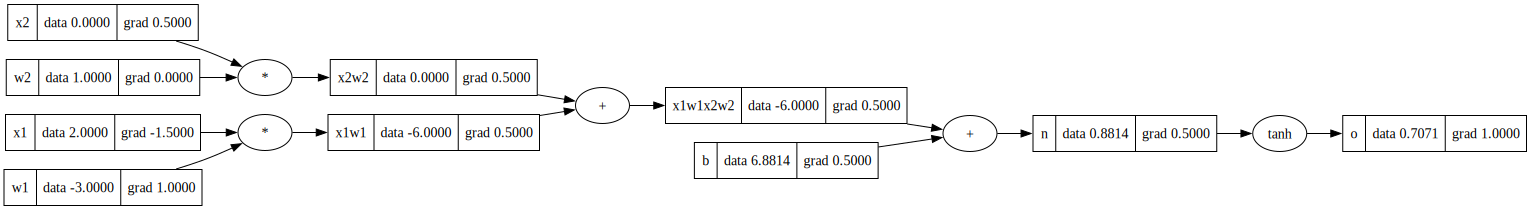

In [70]:
draw_dot(o)

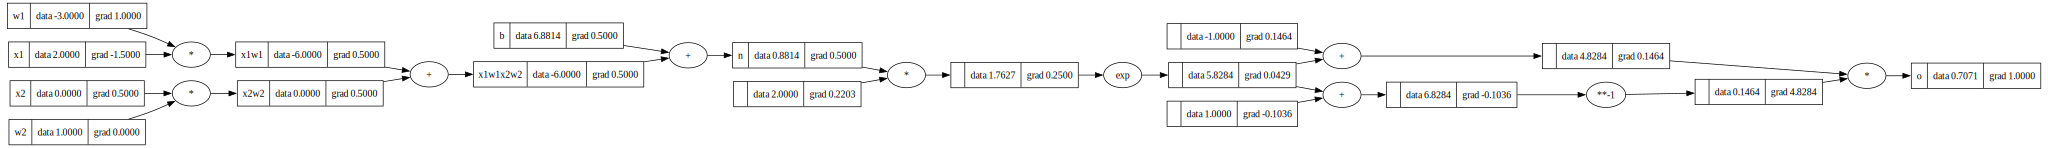

In [86]:
## Breaking tanh

# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1w1+x2w2+b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# -------
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'
#--------
o.backward()
draw_dot(o)

In [57]:
o.grad = 1.0

In [ ]:
# Manual Backpropagation
n.grad = 0.5
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad
w2.grad = x2.data * x2w2.grad
x2.grad = w2.data * x2w2.grad


In [49]:
o.grad = 1.0

In [ ]:
# Automatic Backpropagation
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

In [69]:
# backward Pass with topological sort 
o.backward()

In [90]:
# PyTorch Implementation

x1 = torch.tensor([2.0]).double()                       ; x1.requires_grad = True
x2 = torch.tensor([0.0]).double()                       ; x2.requires_grad = True
w1 = torch.tensor([-3.0]).double()                      ; w1.requires_grad = True
w2 = torch.tensor([1.0]).double()                       ; w2.requires_grad = True
b = torch.tensor([6.8813735870195432]).double()         ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print(x1.grad.data.item())
print(x2.grad.data.item())
print(w1.grad.data.item())
print(w2.grad.data.item())

0.7071066904050358
-1.5000003851533106
0.5000001283844369
1.0000002567688737
0.0


In [ ]:

import random


class Neuron: # Single Neuron

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # Weighted sum of inputs + bias

        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer: # Layer of Neurons

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP: # Multi-Layer Perceptron

    def __init__(self, nin, nouts):
        sz = [nin] + nouts 
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x[0]  # Return the output of the last layer (assuming single output) 

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
x = [2.0, 3.0, -1.0]
mlp = MLP(3, [4, 4, 1])  # Assuming you want an MLP with 3 inputs, 2 hidden layers of 4 neurons each, and 1 output
out = mlp(x)

In [142]:
mlp.parameters()  # This will return the parameters of the MLP, which includes its weights and bias.

[Value(data=0.7940220349860776),
 Value(data=-0.868299180922091),
 Value(data=-0.8877663831423266),
 Value(data=0.7755054115887869),
 Value(data=-0.4528674975921203),
 Value(data=0.419248997212063),
 Value(data=-0.5950481418064362),
 Value(data=-0.16946925147444958),
 Value(data=0.07348874334692779),
 Value(data=0.3659368774358396),
 Value(data=0.9843916130846269),
 Value(data=-0.1884457569981277),
 Value(data=-0.8306682046934777),
 Value(data=-0.07185251514036284),
 Value(data=-0.19535018342484678),
 Value(data=-0.5520380771648714),
 Value(data=-0.8226103053471978),
 Value(data=-0.9810689483014721),
 Value(data=-0.02151400570796458),
 Value(data=-0.22528554313398197),
 Value(data=0.2055516803221369),
 Value(data=0.7989977547970091),
 Value(data=0.7263033671827925),
 Value(data=0.2948528859012871),
 Value(data=0.6833639185345151),
 Value(data=0.2690827313230648),
 Value(data=0.2583043490646344),
 Value(data=0.36599549342239923),
 Value(data=0.7859910080373136),
 Value(data=0.9689164660

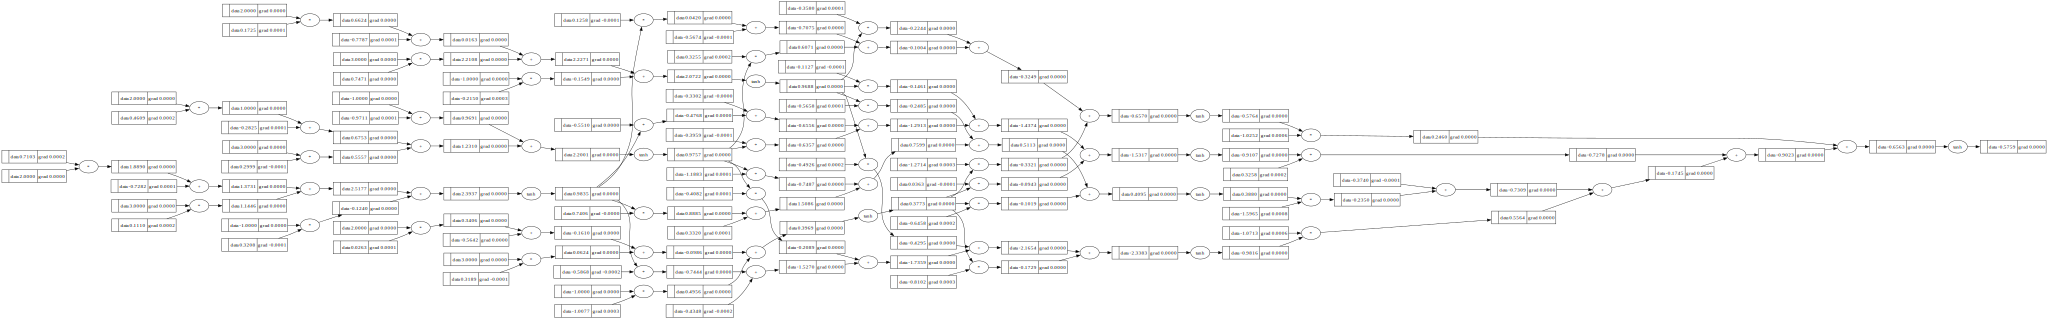

In [212]:
draw_dot(out)

In [151]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

ypreds = [mlp(x) for x in xs]
ypreds

[Value(data=-0.575900089302073),
 Value(data=-0.7669625114628746),
 Value(data=-0.2873344400649966),
 Value(data=-0.5849159505759238)]

In [152]:
# Loss function: Mean Squared Error
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypreds))
loss

Value(data=5.557618333233429)

In [153]:
loss.backward()

In [154]:
mlp.layers[0].neurons[0].w[0].grad  # Example: Accessing the gradient of the first weight of the first neuron in the first layer

0.7019529398356561

In [155]:
for p in mlp.parameters():
    p.data += -0.01 * p.grad  # Update parameters using gradient descent, Negative sign because we want to move in the direction of the negative gradient to minimize the loss.

In [156]:
mlp.layers[0].neurons[0].w[0].grad

0.7019529398356561

In [210]:
for k in range(50):  # Train for 50 epochs
    ypreds = [mlp(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypreds))
    
    # Zero gradients before backward pass
    for p in mlp.parameters():
        p.grad = 0.0
    
    loss.backward()
    
    # Update parameters
    for p in mlp.parameters():
        p.data += -0.05 * p.grad  # Gradient descent step
    print(f"step {k:02d} | loss {loss.data:.4f} | w[0].grad {mlp.layers[0].neurons[0].w[0].grad:.6f}")

step 00 | loss 0.0002 | w[0].grad 0.000171
step 01 | loss 0.0002 | w[0].grad 0.000170
step 02 | loss 0.0002 | w[0].grad 0.000170
step 03 | loss 0.0002 | w[0].grad 0.000170
step 04 | loss 0.0002 | w[0].grad 0.000170
step 05 | loss 0.0002 | w[0].grad 0.000170
step 06 | loss 0.0002 | w[0].grad 0.000170
step 07 | loss 0.0002 | w[0].grad 0.000170
step 08 | loss 0.0002 | w[0].grad 0.000170
step 09 | loss 0.0002 | w[0].grad 0.000170
step 10 | loss 0.0002 | w[0].grad 0.000170
step 11 | loss 0.0002 | w[0].grad 0.000170
step 12 | loss 0.0002 | w[0].grad 0.000169
step 13 | loss 0.0002 | w[0].grad 0.000169
step 14 | loss 0.0002 | w[0].grad 0.000169
step 15 | loss 0.0002 | w[0].grad 0.000169
step 16 | loss 0.0002 | w[0].grad 0.000169
step 17 | loss 0.0002 | w[0].grad 0.000169
step 18 | loss 0.0002 | w[0].grad 0.000169
step 19 | loss 0.0002 | w[0].grad 0.000169
step 20 | loss 0.0002 | w[0].grad 0.000169
step 21 | loss 0.0002 | w[0].grad 0.000169
step 22 | loss 0.0002 | w[0].grad 0.000169
step 23 | l

In [211]:
ypreds

[Value(data=0.9928867720151928),
 Value(data=-0.9938891348362833),
 Value(data=-0.9928498692585447),
 Value(data=0.9913707121038184)]